# PyMC-2 : Distributions Gaussiennes et Melanges

**Equivalent Infer.NET** : [Infer-2-Gaussian-Mixtures](../Infer/Infer-2-Gaussian-Mixtures.ipynb)

**Objectifs** :
- Modeliser des donnees gaussiennes avec PyMC
- Implementer le scenario du cycliste (temps de trajet)
- Comprendre les priors conjugues Normal-Gamma
- Predire et calculer des probabilites
- Implementer un melange de gaussiennes (GMM) pour gerer les evenements extraordinaires

## 1. Le Scenario du Cycliste

Vous vous rendez au travail a velo chaque jour. Votre temps de trajet varie.
Apres quelques jours d'observation, vous voulez :
- Estimer votre temps moyen
- Predire le temps de demain
- Detecter les jours exceptionnels (melange de distributions)

In [1]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from scipy import stats
import matplotlib.pyplot as plt

print(f"PyMC version: {pm.__version__}")

PyMC version: 5.28.5


## 2. Modele Simple : Une Gaussienne

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Moyenne | `Variable.GaussianFromMeanAndPrecision(m, p)` | `pm.Normal('mu', mu=m, tau=p)` |
| Precision | `Variable.GammaFromShapeAndScale(s, r)` | `pm.Gamma('tau', alpha=s, beta=1/r)` |
| Observation | `Variable.GaussianFromMeanAndPrecision(mu, tau)` | `pm.Normal('x', mu=mu, tau=tau, observed=data)` |

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, tau]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 29 seconds.


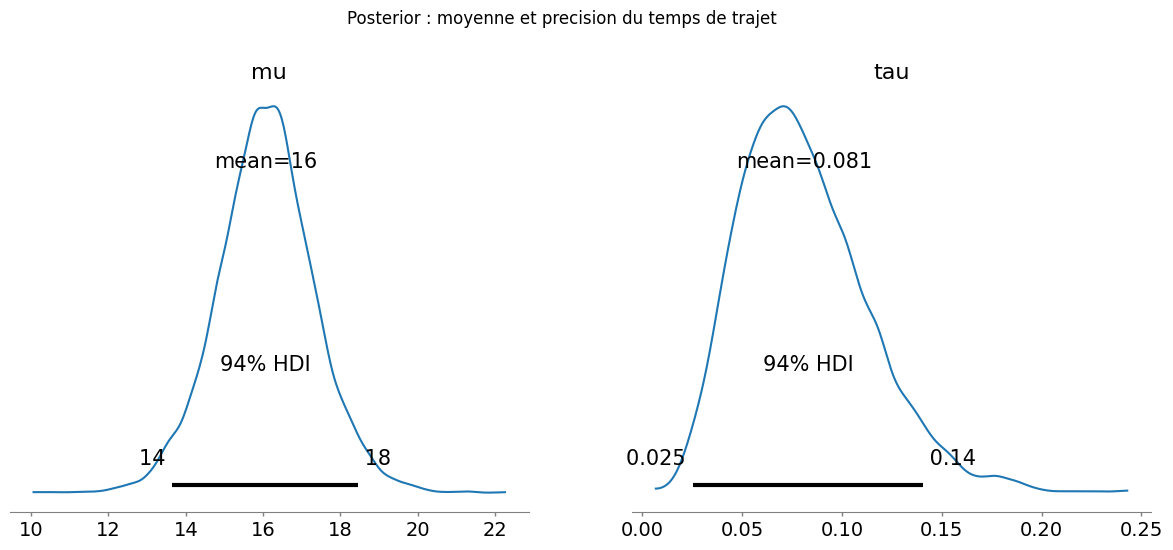

Moyenne posterior: 16.08 min (ecart-type: 1.25)
Precision posterior: 0.08
Ecart-type posterior: 3.51 min


In [2]:
# Donnees observees : temps de trajet (minutes)
donnees_trajets = np.array([13.0, 17.0, 20.0, 25.0, 16.0, 11.0, 16.0, 14.0, 13.0])

# Modele PyMC : Gaussienne avec priors vagues
# Equivalent Infer.NET : Variable.GaussianFromMeanAndPrecision + Variable.GammaFromShapeAndScale
with pm.Model() as cycliste_simple:
    # Prior sur la moyenne : vague, centree sur 15 min
    mu = pm.Normal('mu', mu=15, sigma=10)
    
    # Prior sur la precision : Gamma vague
    tau = pm.Gamma('tau', alpha=2, beta=1)
    
    # Vraisemblance
    trajets = pm.Normal('trajets', mu=mu, tau=tau, observed=donnees_trajets)
    
    trace_simple = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Resultats
az.plot_posterior(trace_simple, var_names=['mu', 'tau'])
plt.suptitle('Posterior : moyenne et precision du temps de trajet', y=1.02)
plt.show()

mu_post = trace_simple.posterior['mu'].values.flatten()
tau_post = trace_simple.posterior['tau'].values.flatten()
print(f"Moyenne posterior: {mu_post.mean():.2f} min (ecart-type: {mu_post.std():.2f})")
print(f"Precision posterior: {tau_post.mean():.2f}")
print(f"Ecart-type posterior: {1/np.sqrt(tau_post.mean()):.2f} min")

## 3. Prediction du Temps de Demain

La **distribution predictive posterior** combine l'incertitude sur les parametres avec la variabilite naturelle du modele.

Sampling: [trajets]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

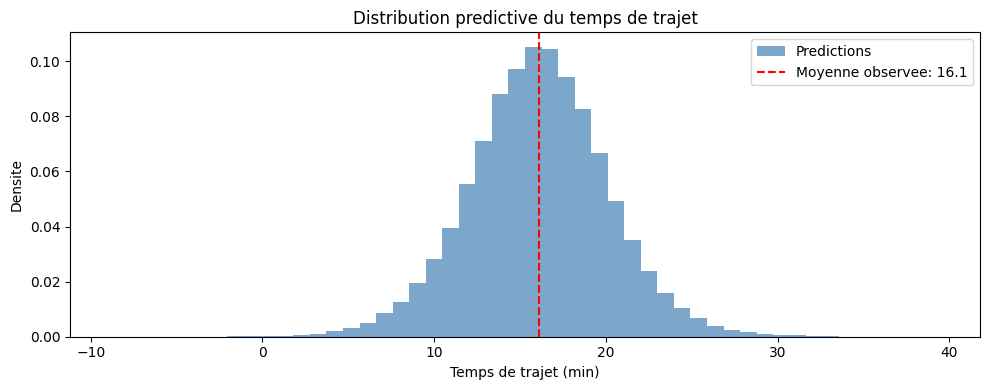

P(trajet < 18 min) = 0.694
P(trajet > 25 min) = 0.016
P(14 < trajet < 20 min) = 0.555


In [3]:
# Prediction : echantillons de la distribution predictive
with cycliste_simple:
    ppc = pm.sample_posterior_predictive(trace_simple, random_seed=42)

predictions = ppc.posterior_predictive['trajets'].values.flatten()

# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(predictions, bins=50, density=True, alpha=0.7, color='steelblue', label='Predictions')
ax.axvline(donnees_trajets.mean(), color='red', linestyle='--', label=f'Moyenne observee: {donnees_trajets.mean():.1f}')
ax.set_xlabel('Temps de trajet (min)')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('Distribution predictive du temps de trajet')
plt.tight_layout()
plt.show()

# Probabilites
print(f"P(trajet < 18 min) = {(predictions < 18).mean():.3f}")
print(f"P(trajet > 25 min) = {(predictions > 25).mean():.3f}")
print(f"P(14 < trajet < 20 min) = {((predictions > 14) & (predictions < 20)).mean():.3f}")

## 4. Gaussienne Tronquee

Une gaussienne tronquee restreint les valeurs a un intervalle. Utile quand une variable ne peut pas etre negative (temps, distances, etc.).

In [4]:
# Gaussienne tronquee : temps de trajet ne peut pas etre negatif
# Equivalent Infer.NET : Variable.GaussianFromMeanAndPrecision + Variable.ConstrainBetween

with pm.Model() as cycliste_tronque:
    mu = pm.Normal('mu', mu=15, sigma=10)
    tau = pm.Gamma('tau', alpha=2, beta=1)
    
    # Tronquee a [0, +inf)
    trajets = pm.TruncatedNormal('trajets', mu=mu, tau=tau, lower=0, observed=donnees_trajets)
    
    trace_tronq = pm.sample(3000, random_seed=42, return_inferencedata=True)

mu_tronq = trace_tronq.posterior['mu'].values.flatten()
print(f"Moyenne (tronquee) : {mu_tronq.mean():.2f} min")
print(f"Ecart-type (tronquee) : {1/np.sqrt(trace_tronq.posterior['tau'].values.flatten().mean()):.2f} min")
print()
print("La troncature a peu d'effet ici car les donnees sont bien positives.")
print("Elle devient importante quand le prior couvre des valeurs negatives.")

Initializing NUTS using jitter+adapt_diag...


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, tau]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 34 seconds.


Moyenne (tronquee) : 16.09 min
Ecart-type (tronquee) : 3.50 min

La troncature a peu d'effet ici car les donnees sont bien positives.
Elle devient importante quand le prior couvre des valeurs negatives.


## 5. Melange de Gaussiennes (GMM)

Les donnees contiennent des evenements extraordinaires (jours ou le trajet est beaucoup plus long). Un melange de gaussiennes capture cette structure :
- **Composante 1** : trajet normal (moyenne ~15 min)
- **Composante 2** : trajet exceptionnel (moyenne ~30 min)

### Architecture Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Variable de melange | `Variable.Switch(idx, components)` | `pm.Mixture` ou `pm.NormalMixture` |
| Poids du melange | `Variable.Discrete(probs)` | `pm.Categorical` (interne a Mixture) |
| Composantes | Array de Gaussiennes | Liste de distributions |

In [5]:
# Donnees avec evenements extraordinaires
donnees_mixtes = np.array([13.0, 17.0, 20.0, 25.0, 16.0, 11.0, 16.0, 14.0, 13.0, 32.0, 35.0, 28.0])

# Modele de melange a 2 composantes
# Equivalent Infer.NET : Variable.Discrete + Variable.Switch
K = 2  # nombre de composantes

with pm.Model() as cycliste_mixte:
    # Poids du melange (quelle composante ?)
    w = pm.Dirichlet('w', a=np.ones(K))
    
    # Moyennes des composantes
    mu_components = pm.Normal('mu_components', mu=np.array([15, 30]), sigma=10, shape=K)
    
    # Ecarts-types des composantes
    sigma_components = pm.HalfNormal('sigma_components', sigma=5, shape=K)
    
    # Assignation des observations aux composantes
    z = pm.Categorical('z', p=w, shape=len(donnees_mixtes))
    
    # Vraisemblance
    mu_obs = mu_components[z]
    sigma_obs = sigma_components[z]
    trajets = pm.Normal('trajets', mu=mu_obs, sigma=sigma_obs, observed=donnees_mixtes)
    
    trace_mixte = pm.sample(3000, random_seed=42, return_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>NUTS: [w, mu_components, sigma_components]


>BinaryGibbsMetropolis: [z]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 46 seconds.


There were 271 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


=== Modele de Melange a 2 Composantes ===
Composante 1 : mu=17.3 min, sigma=4.2 min, poids=0.56
Composante 2 : mu=26.1 min, sigma=5.5 min, poids=0.44


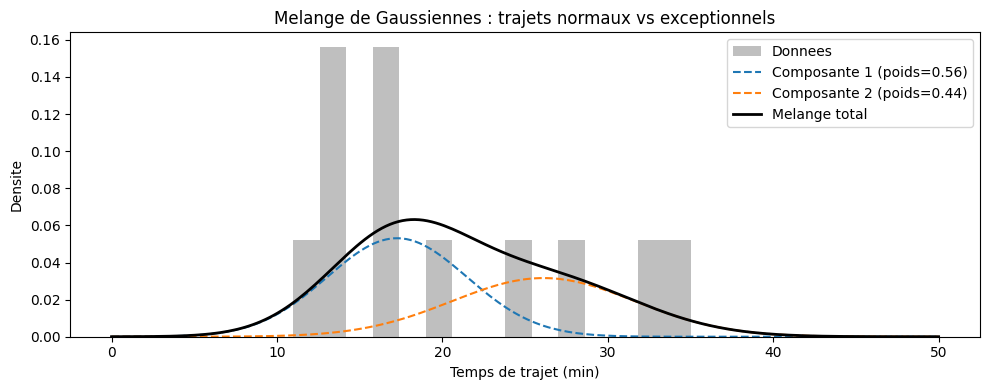

In [6]:
# Resultats du melange
mu_comp = trace_mixte.posterior['mu_components'].values.reshape(-1, K)
sigma_comp = trace_mixte.posterior['sigma_components'].values.reshape(-1, K)
w_post = trace_mixte.posterior['w'].values.reshape(-1, K)

# Identifier les composantes par ordre de moyenne
order = np.argsort(mu_comp.mean(axis=0))

print("=== Modele de Melange a 2 Composantes ===")
for i, idx in enumerate(order):
    print(f"Composante {i+1} : mu={mu_comp[:, idx].mean():.1f} min, "
          f"sigma={sigma_comp[:, idx].mean():.1f} min, "
          f"poids={w_post[:, idx].mean():.2f}")

# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
x = np.linspace(0, 50, 200)
ax.hist(donnees_mixtes, bins=15, density=True, alpha=0.5, color='gray', label='Donnees')

for i, idx in enumerate(order):
    component = stats.norm(mu_comp[:, idx].mean(), sigma_comp[:, idx].mean())
    ax.plot(x, w_post[:, idx].mean() * component.pdf(x), '--',
            label=f'Composante {i+1} (poids={w_post[:, idx].mean():.2f})')

# Melange total
mixture_pdf = sum(w_post[:, idx].mean() * stats.norm(mu_comp[:, idx].mean(), sigma_comp[:, idx].mean()).pdf(x)
                  for idx in order)
ax.plot(x, mixture_pdf, 'k-', linewidth=2, label='Melange total')
ax.set_xlabel('Temps de trajet (min)')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('Melange de Gaussiennes : trajets normaux vs exceptionnels')
plt.tight_layout()
plt.show()

## 6. Version plus simple avec pm.NormalMixture

PyMC offre une API plus directe pour les melanges gaussiens.

In [7]:
# Version avec pm.NormalMixture (API plus directe)
with pm.Model() as cycliste_normal_mixture:
    w = pm.Dirichlet('w', a=np.ones(K))
    mu_comp = pm.Normal('mu_comp', mu=np.array([15, 30]), sigma=10, shape=K)
    sigma_comp = pm.HalfNormal('sigma_comp', sigma=5, shape=K)
    
    # NormalMixture combine directement les composantes
    trajets = pm.NormalMixture('trajets', w=w, mu=mu_comp, sigma=sigma_comp,
                               observed=donnees_mixtes)
    
    trace_nm = pm.sample(3000, random_seed=42, return_inferencedata=True)

mu_nm = trace_nm.posterior['mu_comp'].values.reshape(-1, K)
order_nm = np.argsort(mu_nm.mean(axis=0))
print("=== NormalMixture (API directe) ===")
for i, idx in enumerate(order_nm):
    print(f"Composante {i+1} : mu={mu_nm[:, idx].mean():.1f} min")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [w, mu_comp, sigma_comp]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 35 seconds.


There were 13 divergences after tuning. Increase `target_accept` or reparameterize.


=== NormalMixture (API directe) ===
Composante 1 : mu=16.6 min
Composante 2 : mu=26.7 min


## 7. Comparaison Infer.NET vs PyMC pour les gaussiennes

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Prior conjugue | Normal-Gamma exact | NUTS echantillonnage (approximation) |
| Precision/Variance | `GammaFromShapeAndScale` (precision) | `HalfNormal` / `Gamma` (sigma ou tau) |
| Melange | `Variable.Switch(idx, values)` | `pm.NormalMixture` ou `pm.Mixture` |
| Gaussienne tronquee | `ConstrainBetween` | `pm.TruncatedNormal` |
| Performance | EP (analytique) | MCMC (plus lent mais general) |

## Exercice : Melange a 3 Composantes

Modifiez le modele de melange pour utiliser 3 composantes au lieu de 2 :
- Composante 1 : trajets rapides (~10 min)
- Composante 2 : trajets normaux (~16 min)
- Composante 3 : trajets lents (~30 min)

**Indices** :
- Changer `K = 3`
- Ajuster les priors : `mu=np.array([10, 16, 30])`
- Utiliser `pm.NormalMixture` comme dans la section 6

In [8]:
# TODO etudiant : implementer le melange a 3 composantes
# Resultat attendu : 3 composantes avec moyennes proches de 10, 16 et 30 min

print("Exercice a completer")

Exercice a completer
